# Project submission

### Group number:
### Student IDs:
### Project name: Crypto Future Price Estimate for Market Making


## What business problem are you solving?

As one of the most volatile assets, crypto assets pose a severe risk for any kind of firm involved in crypto trading activity, such as centralized exchanges like Coinbase or Binance, crypto asset management firms, or venture capitals like a16z, or traditional finance firms and financial services providers such as Revolut that allow users to trade assets.

In order to decrease inventory risk and also allow firms to take an informed stance on the future price of crypto assets, we want to create a simple model which, via a simple regression, allows the prediction of future asset prices. This would allow any business user to request a price prediction via a simple Excel spreadsheet or Python script. However, the difficulty lies in determining which features are actually important for the regression and which are just noise.

## What is the machine learning problem that you are solving?

The machine learning problem we are trying to solve is relatively simple. What we are trying to do is build a simple regression model, specifically a Ridge regression or L2 penalization model, to predict the future price. The actual difficulty lies not in performing the regression itself, but in finding which parameters are actually important.
Therefore, we start by clustering the assets into different groups so that we can find features that are important per class. 

After this, we develop trees of different depths to see which features actually hold, and develop SHAP values, ICE plots, and PDP plots to further analyze which features are important and which are just noise that can be neglected.
The actual difficulty here is to not overfit, but also to generalize well, while still making sure that the model is accurate and not too generalized

## Data exploration and preparation

We start with the same style used in the class notebooks: basic imports, `pandas` data checks, simple visualizations, and `sklearn` models.


In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import davies_bouldin_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")


### Load the data

In [2]:
df_raw = pd.read_csv("pr15_crypto.csv")

if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

print("Shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes)

Shape: (104324, 11)


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


Asset_ID               int64
timestamp     datetime64[ns]
Count                float64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume               float64
VWAP                 float64
Weight               float64
Asset_Name            object
dtype: object

In [3]:
try:
    data_dictionary = pd.read_excel("pr15_data_dictionary.xlsx")
    display(data_dictionary)
except ImportError:
    print("The data dictionary is an Excel file. Install openpyxl to display it in this notebook.")

The data dictionary is an Excel file. Install openpyxl to display it in this notebook.


### Basic data checks

We check rows, duplicates, missing values, infinite values, asset coverage, and the time range.

In [4]:
print("Number of rows:", len(df_raw))
print("Number of duplicate rows:", df_raw.duplicated().sum())
print("Date range:", df_raw["timestamp"].min(), "to", df_raw["timestamp"].max())
print("Number of assets:", df_raw["Asset_Name"].nunique())

display(df_raw.isna().sum().to_frame("missing_values"))

numeric_columns_raw = df_raw.select_dtypes(include="number").columns
inf_counts = np.isinf(df_raw[numeric_columns_raw]).sum()
display(inf_counts[inf_counts > 0].to_frame("infinite_values"))

Number of rows: 104324
Number of duplicate rows: 0
Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00
Number of assets: 14


,missing_values
Asset_ID,0
timestamp,0
Count,0
Open,0
High,0
Low,0
Close,0
Volume,0
VWAP,0
Weight,0


,infinite_values
VWAP,6


In [5]:
asset_summary = (
    df_raw.groupby("Asset_Name")
    .agg(
        rows=("Close", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        min_close=("Close", "min"),
        max_close=("Close", "max"),
    )
    .sort_values("rows", ascending=False)
)

display(asset_summary)

,rows,first_timestamp,last_timestamp,min_close,max_close
Asset_Name,,,,,
Bitcoin,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,3165.973333,64530.898571
Bitcoin Cash,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,74.460000,2856.856667
EOS.IO,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,1.663300,22.504250
Ethereum,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,82.298250,4334.685714
Ethereum Classic,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,3.407050,148.242700
Litecoin,8154,2018-01-01 00:00:00,2021-09-20 20:00:00,22.850750,409.043000
Monero,8152,2018-01-01 00:00:00,2021-09-20 20:00:00,30.225000,515.620000
Binance Coin,8140,2018-01-01 00:00:00,2021-09-20 20:00:00,4.316300,683.385000
TRON,7933,2018-02-06 20:00:00,2021-09-20 20:00:00,0.008507,0.174305


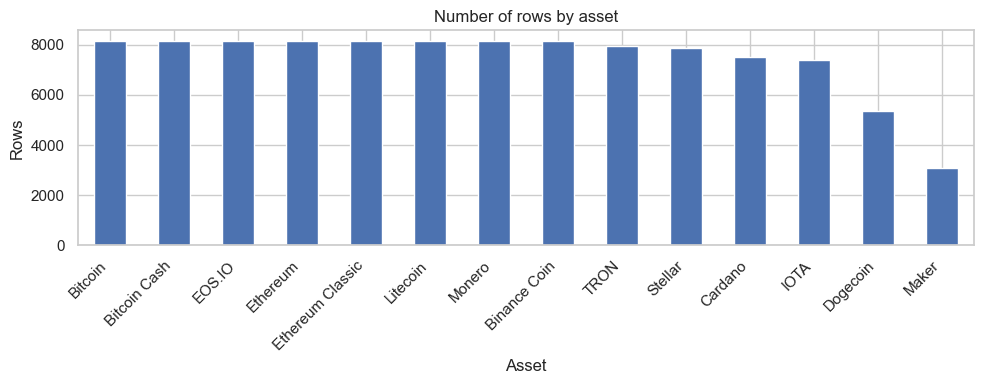

In [6]:
plt.figure(figsize=(10, 4))
df_raw["Asset_Name"].value_counts().plot(kind="bar")
plt.title("Number of rows by asset")
plt.ylabel("Rows")
plt.xlabel("Asset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

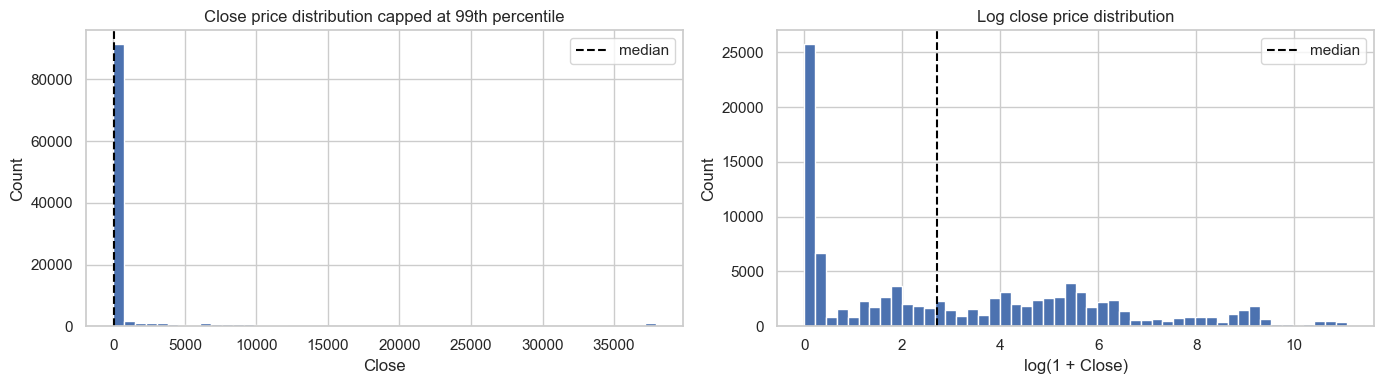

In [7]:
close_for_plot = pd.to_numeric(df_raw["Close"], errors="coerce")
close_for_plot = close_for_plot.replace([np.inf, -np.inf], np.nan).dropna()

close_99 = close_for_plot.quantile(0.99)
close_capped = close_for_plot.clip(upper=close_99)
log_close_for_plot = np.log1p(close_for_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(close_capped, bins=50)
axes[0].axvline(close_for_plot.median(), color="black", linestyle="--", label="median")
axes[0].set_title("Close price distribution capped at 99th percentile")
axes[0].set_xlabel("Close")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(log_close_for_plot, bins=50)
axes[1].axvline(log_close_for_plot.median(), color="black", linestyle="--", label="median")
axes[1].set_title("Log close price distribution")
axes[1].set_xlabel("log(1 + Close)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


The dataset has no missing values and no duplicate rows. `VWAP` has a few infinite values, so those rows are removed before feature engineering.

## Clustering the assets

First we cluster the assets. The goal is to group assets with similar historical behavior before doing regression. We compare a few clustering methods, but keep KMeans as the cluster feature because it is simple and easy to explain.

The clustering summaries are built using only the earlier part of the sample, roughly the same period as the training data.

In [8]:
cluster_training_cutoff = df_raw["timestamp"].quantile(0.70)

df_cluster = df_raw[df_raw["timestamp"] <= cluster_training_cutoff].sort_values(
    ["Asset_ID", "timestamp"]
).copy()

numeric_columns = df_cluster.select_dtypes(include="number").columns
df_cluster[numeric_columns] = df_cluster[numeric_columns].replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna(subset=["Close", "Volume", "VWAP", "Count"])

asset_group_cluster = df_cluster.groupby("Asset_ID", group_keys=False)
df_cluster["return_4h"] = asset_group_cluster["Close"].pct_change()

asset_cluster_features = (
    df_cluster.groupby(["Asset_ID", "Asset_Name"])
    .agg(
        mean_close=("Close", "mean"),
        mean_volume=("Volume", "mean"),
        mean_count=("Count", "mean"),
        mean_return_4h=("return_4h", "mean"),
        volatility_4h=("return_4h", "std"),
        worst_return_4h=("return_4h", "min"),
    )
    .reset_index()
)

for column in ["mean_close", "mean_volume", "mean_count"]:
    asset_cluster_features[f"log_{column}"] = np.log1p(asset_cluster_features[column])

cluster_feature_columns = [
    "log_mean_close",
    "log_mean_volume",
    "log_mean_count",
    "mean_return_4h",
    "volatility_4h",
    "worst_return_4h",
]

asset_cluster_features = asset_cluster_features.dropna(subset=cluster_feature_columns)

print("Clustering uses data up to:", cluster_training_cutoff)
display(asset_cluster_features[["Asset_Name"] + cluster_feature_columns])

Clustering uses data up to: 2020-09-13 08:00:00


,Asset_Name,log_mean_close,log_mean_volume,log_mean_count,mean_return_4h,volatility_4h,worst_return_4h
0,Binance Coin,2.842460,12.899740,9.358667,0.000487,0.023543,-0.226789
1,Bitcoin,8.970966,9.957915,11.899587,0.000086,0.016173,-0.199033
2,Bitcoin Cash,6.185258,10.673766,10.063616,-0.000083,0.024990,-0.273476
3,Cardano,0.078444,17.861483,9.465949,0.000047,0.021719,-0.217697
4,Dogecoin,0.002624,18.419416,7.619103,0.000165,0.018414,-0.169656
5,EOS.IO,1.816057,15.354811,10.561959,0.000143,0.025098,-0.214668
6,Ethereum,5.728074,12.363909,11.266628,0.000098,0.020621,-0.213085
7,Ethereum Classic,2.387977,13.312525,9.515300,-0.000020,0.023738,-0.254540
8,IOTA,0.344924,14.405952,7.997145,-0.000165,0.022147,-0.244429
9,Litecoin,4.367147,12.223703,10.178603,-0.000021,0.021591,-0.203757


### Choosing and comparing clusters

Following the clustering notebook, we scale the features first and compare cluster quality with the elbow method, silhouette score, and Davies-Bouldin index.

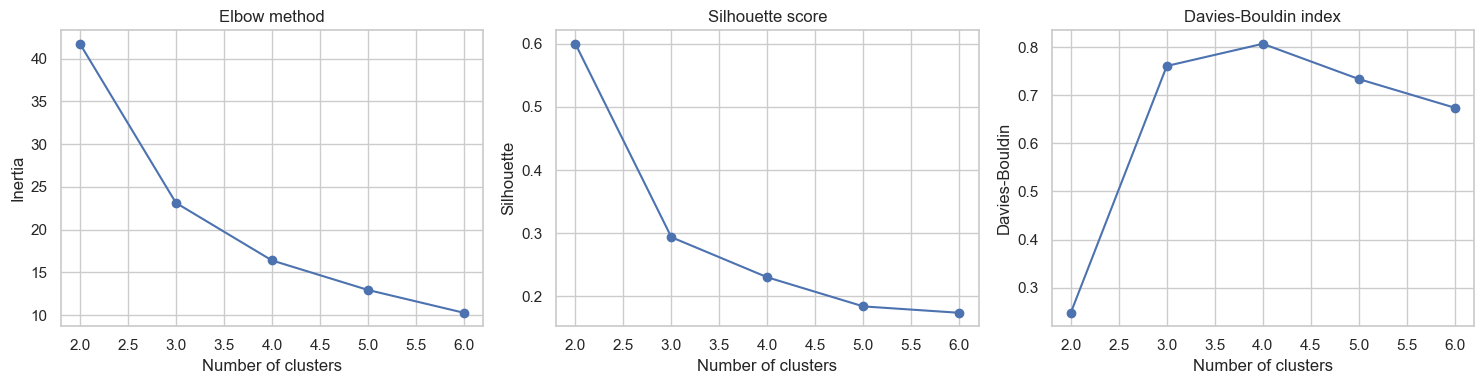

,k,inertia,silhouette_score,davies_bouldin_score
0,2,41.738151,0.600074,0.247576
1,3,23.131091,0.293634,0.761084
2,4,16.400367,0.230087,0.807254
3,5,12.946830,0.183980,0.733886
4,6,10.275420,0.173846,0.674174


In [9]:
cluster_scaler = StandardScaler()
X_assets_scaled = cluster_scaler.fit_transform(asset_cluster_features[cluster_feature_columns])

k_values = range(2, 7)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    cluster_labels = kmeans.fit_predict(X_assets_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_assets_scaled, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_assets_scaled, cluster_labels))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(list(k_values), inertias, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(k_values), silhouette_scores, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Number of clusters")
ax[1].set_ylabel("Silhouette")

ax[2].plot(list(k_values), davies_bouldin_scores, marker="o")
ax[2].set_title("Davies-Bouldin index")
ax[2].set_xlabel("Number of clusters")
ax[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "davies_bouldin_score": davies_bouldin_scores,
}))

In [10]:
chosen_k = 3

clustering_models = {
    "KMeans": KMeans(n_clusters=chosen_k, random_state=SEED, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=chosen_k),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=2),
}

clustering_results = []

for method_name, clustering_model in clustering_models.items():
    labels = clustering_model.fit_predict(X_assets_scaled)
    labels_for_score = labels[labels != -1]
    X_for_score = X_assets_scaled[labels != -1]
    n_clusters = len(set(labels_for_score))
    n_noise = (labels == -1).sum()

    if n_clusters > 1 and len(labels_for_score) > n_clusters:
        silhouette = silhouette_score(X_for_score, labels_for_score)
        davies_bouldin = davies_bouldin_score(X_for_score, labels_for_score)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    asset_cluster_features[f"{method_name}_cluster"] = labels
    clustering_results.append({
        "method": method_name,
        "number_of_clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
    })

clustering_results = pd.DataFrame(clustering_results)
display(clustering_results)

asset_cluster_features["asset_cluster"] = asset_cluster_features["KMeans_cluster"]
display(asset_cluster_features[["Asset_ID", "Asset_Name", "asset_cluster"]].sort_values(["asset_cluster", "Asset_Name"]))

,method,number_of_clusters,noise_points,silhouette_score,davies_bouldin_score
0,KMeans,3,0,0.293634,0.761084
1,Agglomerative,3,0,0.281457,0.729197
2,DBSCAN,1,5,NaN,NaN


,Asset_ID,Asset_Name,asset_cluster
1,1,Bitcoin,0
2,2,Bitcoin Cash,0
6,6,Ethereum,0
9,9,Litecoin,0
11,11,Monero,0
10,10,Maker,1
0,0,Binance Coin,2
3,3,Cardano,2
4,4,Dogecoin,2
5,5,EOS.IO,2


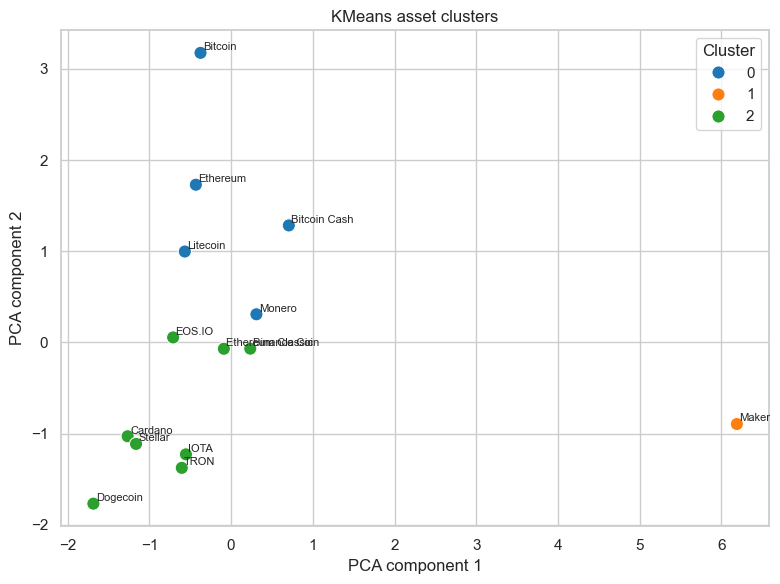

In [11]:
pca = PCA(n_components=2, random_state=SEED)
asset_pca = pca.fit_transform(X_assets_scaled)

asset_cluster_features["pca_1"] = asset_pca[:, 0]
asset_cluster_features["pca_2"] = asset_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=asset_cluster_features,
    x="pca_1",
    y="pca_2",
    hue="asset_cluster",
    palette="tab10",
    s=90,
)

for _, row in asset_cluster_features.iterrows():
    plt.text(row["pca_1"] + 0.03, row["pca_2"] + 0.03, row["Asset_Name"], fontsize=8)

plt.title("KMeans asset clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Feature engineering

For supervised learning, we create a historical future-price label from the realized price at the next timestamp. This label tells the model what it should have predicted. The realized future price is never included as an input feature.

The feature set stays simple: price, volume, candle, lag, rolling volatility, cross-asset, calendar, and cluster features. The cross-asset features include the average return of the other assets plus Bitcoin and Ethereum returns.

In [12]:
df = df_raw.sort_values(["Asset_ID", "timestamp"]).copy()

numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume", "VWAP", "Count", "Weight"])

asset_cluster_lookup = asset_cluster_features[["Asset_ID", "asset_cluster"]]
df = df.merge(asset_cluster_lookup, on="Asset_ID", how="left")

asset_group = df.groupby("Asset_ID", group_keys=False)

# Historical label for training: realized future price at the next timestamp.
# This column is the target, not an input feature.
df["future_price"] = asset_group["Close"].shift(-1)

df["candle_return"] = df["Close"] / df["Open"] - 1
df["high_low_range_pct"] = (df["High"] - df["Low"]) / df["Open"]
df["close_vwap_gap_pct"] = (df["Close"] - df["VWAP"]) / df["VWAP"]
df["volume_log"] = np.log1p(df["Volume"])
df["count_log"] = np.log1p(df["Count"])

df["return_4h"] = asset_group["Close"].pct_change(1)
df["return_8h"] = asset_group["Close"].pct_change(2)
df["return_24h"] = asset_group["Close"].pct_change(6)
df["rolling_return_mean_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).mean()
)
df["rolling_volatility_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(window=6, min_periods=3).std()
)
df["rolling_volume_mean_24h"] = asset_group["Volume"].transform(
    lambda s: s.rolling(window=6, min_periods=3).mean()
)
df["volume_change_4h"] = asset_group["Volume"].pct_change(1)

timestamp_group = df.groupby("timestamp")
df["assets_at_timestamp"] = timestamp_group["return_4h"].transform("count")
df["market_return_4h"] = timestamp_group["return_4h"].transform("mean")
df["market_volatility_4h"] = timestamp_group["return_4h"].transform("std")
df["other_assets_return_4h"] = (
    df["market_return_4h"] * df["assets_at_timestamp"] - df["return_4h"]
) / (df["assets_at_timestamp"] - 1)

asset_return_table = df.pivot_table(index="timestamp", columns="Asset_Name", values="return_4h")
df["bitcoin_return_4h"] = df["timestamp"].map(asset_return_table["Bitcoin"])
df["ethereum_return_4h"] = df["timestamp"].map(asset_return_table["Ethereum"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

candidate_features = [
    "asset_cluster",
    "Count",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "VWAP",
    "Weight",
    "candle_return",
    "high_low_range_pct",
    "close_vwap_gap_pct",
    "volume_log",
    "count_log",
    "return_4h",
    "return_8h",
    "return_24h",
    "rolling_return_mean_24h",
    "rolling_volatility_24h",
    "rolling_volume_mean_24h",
    "market_return_4h",
    "other_assets_return_4h",
    "market_volatility_4h",
    "bitcoin_return_4h",
    "ethereum_return_4h",
    "volume_change_4h",
    "hour",
    "day_of_week",
    "month",
]

df_model = df.dropna(subset=candidate_features + ["future_price"]).copy()
df_model = df_model.sort_values(["timestamp", "Asset_ID"]).reset_index(drop=True)

print("Shape after feature engineering:", df_model.shape)
display(df_model[["timestamp", "Asset_Name"] + candidate_features + ["future_price"]].head())

Shape after feature engineering: (104220, 34)


,timestamp,Asset_Name,asset_cluster,Count,Open,High,Low,Close,Volume,VWAP,Weight,candle_return,high_low_range_pct,close_vwap_gap_pct,volume_log,count_log,return_4h,return_8h,return_24h,rolling_return_mean_24h,rolling_volatility_24h,rolling_volume_mean_24h,market_return_4h,other_assets_return_4h,market_volatility_4h,bitcoin_return_4h,ethereum_return_4h,volume_change_4h,hour,day_of_week,month,future_price
0,2018-01-02,Binance Coin,2,5852.0,8.450000,8.6599,8.340,8.3986,245387.240000,8.491222,4.304065,-0.006083,0.037858,-0.010908,12.410597,8.674710,-0.006083,0.034948,0.007014,0.001358,0.021653,127230.356667,0.041166,0.047916,0.036968,-0.005328,0.090647,1.873164,0,1,1,8.3100
1,2018-01-02,Bitcoin,0,101478.0,13427.492000,13999.0000,13200.000,13361.3440,17001.646278,13620.253646,6.779922,-0.004926,0.059505,-0.019009,9.741124,11.527607,-0.005328,0.001727,-0.010050,-0.001594,0.014427,10691.015901,0.041166,0.047809,0.036968,-0.005328,0.090647,0.668656,0,1,1,13433.4000
2,2018-01-02,Bitcoin Cash,0,25712.0,2320.886667,2449.5000,2301.670,2375.5100,10974.484639,2386.746293,2.397895,0.023536,0.063695,-0.004708,9.303419,10.154752,0.023256,0.029670,0.012793,0.002300,0.020646,5069.853424,0.041166,0.043725,0.036968,-0.005328,0.090647,2.090221,0,1,1,2340.9150
3,2018-01-02,EOS.IO,2,6014.0,7.640100,8.6000,7.622,8.2216,912278.064362,8.289561,1.386294,0.076112,0.128009,-0.008198,13.723701,8.702012,0.076407,0.080666,0.078115,0.013197,0.037840,387111.007180,0.041166,0.036132,0.036968,-0.005328,0.090647,2.294062,0,1,1,8.1889
4,2018-01-02,Ethereum,0,118792.0,756.225000,899.5000,749.060,824.3900,308228.416759,831.731032,5.894403,0.090139,0.198936,-0.008826,12.638600,11.685138,0.090647,0.099770,0.117412,0.019217,0.036963,90195.419769,0.041166,0.034098,0.036968,-0.005328,0.090647,4.552390,0,1,1,850.0625


### Chronological 70/20/10 split

We keep the requested split: 70% training, 20% test, and 10% validation. The model is fitted on the training set, the validation set is used to choose the Ridge `alpha`, and the final performance is reported on the test set.


In [13]:
n_rows = len(df_model)

train_cutoff = df_model.loc[int(0.70 * n_rows) - 1, "timestamp"]
validation_cutoff = df_model.loc[int(0.80 * n_rows) - 1, "timestamp"]

train_df = df_model[df_model["timestamp"] <= train_cutoff].copy()
validation_df = df_model[
    (df_model["timestamp"] > train_cutoff)
    & (df_model["timestamp"] <= validation_cutoff)
].copy()
test_df = df_model[df_model["timestamp"] > validation_cutoff].copy()

split_summary = pd.DataFrame(
    {
        "requested_share": [0.70, 0.20, 0.10],
        "actual_rows": [len(train_df), len(test_df), len(validation_df)],
        "actual_share": [
            len(train_df) / n_rows,
            len(test_df) / n_rows,
            len(validation_df) / n_rows,
        ],
        "start": [
            train_df["timestamp"].min(),
            test_df["timestamp"].min(),
            validation_df["timestamp"].min(),
        ],
        "end": [
            train_df["timestamp"].max(),
            test_df["timestamp"].max(),
            validation_df["timestamp"].max(),
        ],
        "model_use": [
            "fit Ridge models",
            "final performance measurement",
            "choose Ridge alpha",
        ],
    },
    index=["train", "test", "validation"],
)

display(split_summary)


,requested_share,actual_rows,actual_share,start,end,model_use
train,0.7,72958,0.700038,2018-01-02 00:00:00,2020-09-13 12:00:00,fit Ridge models
test,0.2,20832,0.199885,2021-01-15 20:00:00,2021-09-20 16:00:00,final performance measurement
validation,0.1,10430,0.100077,2020-09-13 16:00:00,2021-01-15 16:00:00,choose Ridge alpha


## Feature importance by cluster

Now we decide which features are important for each cluster. We use decision trees with different depths. If a feature is important across several depths, it is a stronger feature candidate for that cluster.

In [14]:
tree_depths = [2, 4, 6]
cluster_importance_rows = []
cluster_tree_scores = []

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
    cluster_validation = validation_df[validation_df["asset_cluster"] == cluster_id]

    X_cluster_train = cluster_train[candidate_features]
    y_cluster_train = cluster_train["future_price"]

    for depth in tree_depths:
        tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=100,
            random_state=SEED,
        )
        tree.fit(X_cluster_train, y_cluster_train)

        if len(cluster_validation) > 0:
            X_cluster_validation = cluster_validation[candidate_features]
            y_cluster_validation = cluster_validation["future_price"]
            y_pred = tree.predict(X_cluster_validation)

            cluster_tree_scores.append(
                {
                    "cluster": cluster_id,
                    "depth": depth,
                    "validation_MAE": mean_absolute_error(y_cluster_validation, y_pred),
                    "validation_RMSE": np.sqrt(mean_squared_error(y_cluster_validation, y_pred)),
                    "validation_R2": r2_score(y_cluster_validation, y_pred),
                }
            )

        for feature, importance in zip(candidate_features, tree.feature_importances_):
            cluster_importance_rows.append(
                {
                    "cluster": cluster_id,
                    "depth": depth,
                    "feature": feature,
                    "importance": importance,
                }
            )

cluster_tree_scores = pd.DataFrame(cluster_tree_scores)
cluster_importance_df = pd.DataFrame(cluster_importance_rows)

display(cluster_tree_scores)


,cluster,depth,validation_MAE,validation_RMSE,validation_R2
0,0,2,1727.966105,5040.517519,0.602149
1,0,4,1086.657867,3830.457153,0.770242
2,0,6,1032.402253,3828.008134,0.770535
3,1,2,83.344514,196.287347,0.268072
4,1,4,65.018163,193.226887,0.290718
5,1,6,65.018163,193.226887,0.290718
6,2,2,0.959058,2.174207,0.953109
7,2,4,0.316821,0.893615,0.992079
8,2,6,0.140505,0.484785,0.997669


,cluster,feature,importance
0,0,Close,0.998811
5,0,VWAP,0.000904
2,0,High,0.000285
32,1,Low,0.743880
29,1,Close,0.223304
34,1,VWAP,0.022218
33,1,Open,0.010598
58,2,Close,0.996721
61,2,Low,0.003204
63,2,VWAP,0.000061


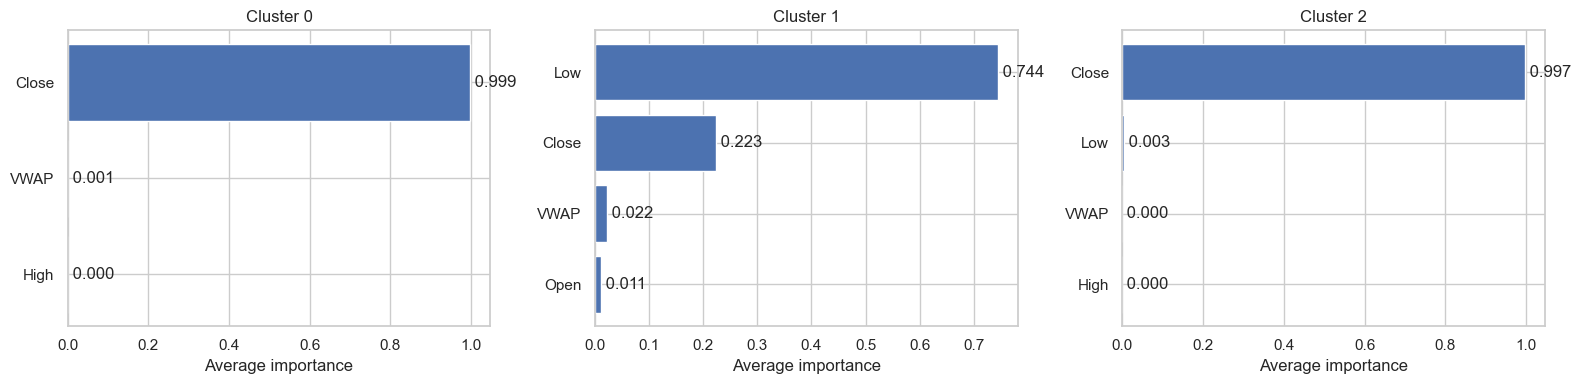

In [15]:
cluster_feature_importance = (
    cluster_importance_df.groupby(["cluster", "feature"])["importance"]
    .mean()
    .reset_index()
    .sort_values(["cluster", "importance"], ascending=[True, False])
)

important_tree_features = cluster_feature_importance[
    cluster_feature_importance["importance"] > 0
].copy()

display(important_tree_features.groupby("cluster").head(8))

clusters = sorted(cluster_feature_importance["cluster"].unique())
fig, axes = plt.subplots(1, len(clusters), figsize=(16, 4))

if len(clusters) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, clusters):
    top_features = important_tree_features[
        important_tree_features["cluster"] == cluster_id
    ].head(6)

    if len(top_features) == 0:
        ax.text(0.5, 0.5, "No non-zero importance", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(top_features["feature"], top_features["importance"])
    ax.invert_yaxis()
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Average importance")
    ax.set_ylabel("")

    for y_position, value in enumerate(top_features["importance"]):
        ax.text(value, y_position, f" {value:.3f}", va="center")

plt.tight_layout()
plt.show()


### SHAP, PDP, ICE, and final feature decisions

The decision trees give the first feature ranking. We then use SHAP, PDP, and ICE in the same style as the interpretability notebook to check which features should be kept and which features should be neglected.

The final Ridge models only use the features marked as `include in Ridge`. Features marked as `do not include in Ridge` are treated as noise or as not useful for an asset-specific regression.


In [16]:
top_n_features = 8
features_not_for_final_regression = ["asset_cluster", "Weight"]

best_depth_by_cluster = (
    cluster_tree_scores.sort_values("validation_MAE")
    .groupby("cluster")["depth"]
    .first()
    .to_dict()
)

cluster_tree_models = {}

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    depth = int(best_depth_by_cluster.get(cluster_id, 4))
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]

    tree = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=100,
        random_state=SEED,
    )
    tree.fit(cluster_train[candidate_features], cluster_train["future_price"])
    cluster_tree_models[cluster_id] = tree

try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("SHAP is not installed, so the feature decision uses tree importance only.")

cluster_shap_rows = []
shap_values_by_cluster = {}
shap_data_by_cluster = {}

if shap_available:
    for cluster_id, tree in cluster_tree_models.items():
        cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
        shap_sample = cluster_train.sample(min(300, len(cluster_train)), random_state=SEED)
        X_shap = shap_sample[candidate_features]

        explainer = shap.TreeExplainer(tree)
        shap_values = explainer.shap_values(X_shap)

        shap_values_by_cluster[cluster_id] = shap_values
        shap_data_by_cluster[cluster_id] = X_shap

        shap_importance = np.abs(shap_values).mean(axis=0)
        for feature, importance in zip(candidate_features, shap_importance):
            cluster_shap_rows.append(
                {
                    "cluster": cluster_id,
                    "feature": feature,
                    "shap_importance": importance,
                }
            )

cluster_shap_importance = pd.DataFrame(cluster_shap_rows)

feature_decision_table = cluster_feature_importance.copy()
feature_decision_table["tree_rank"] = feature_decision_table.groupby("cluster")[
    "importance"
].rank(method="first", ascending=False)

if len(cluster_shap_importance) > 0:
    cluster_shap_importance["shap_rank"] = cluster_shap_importance.groupby("cluster")[
        "shap_importance"
    ].rank(method="first", ascending=False)
    feature_decision_table = feature_decision_table.merge(
        cluster_shap_importance,
        on=["cluster", "feature"],
        how="left",
    )
else:
    feature_decision_table["shap_importance"] = np.nan
    feature_decision_table["shap_rank"] = np.nan

feature_decision_table["eligible_for_final_model"] = ~feature_decision_table[
    "feature"
].isin(features_not_for_final_regression)
feature_decision_table["shap_rank_for_selection"] = feature_decision_table[
    "shap_rank"
].fillna(feature_decision_table["tree_rank"])
feature_decision_table["combined_rank"] = (
    feature_decision_table["tree_rank"]
    + feature_decision_table["shap_rank_for_selection"]
)
feature_decision_table["decision"] = "do not include in Ridge"
feature_decision_table["reason"] = "low importance compared with the selected features"
feature_decision_table.loc[
    ~feature_decision_table["eligible_for_final_model"],
    "reason",
] = "context or cluster feature, not used in the final one-asset Ridge model"

cluster_selected_features = {}
cluster_neglected_features = {}

for cluster_id in sorted(feature_decision_table["cluster"].unique()):
    cluster_rows = feature_decision_table[
        (feature_decision_table["cluster"] == cluster_id)
        & (feature_decision_table["eligible_for_final_model"])
    ].sort_values("combined_rank")

    selected_features = cluster_rows.head(top_n_features)["feature"].tolist()
    cluster_selected_features[cluster_id] = selected_features

    keep_mask = (
        (feature_decision_table["cluster"] == cluster_id)
        & (feature_decision_table["feature"].isin(selected_features))
    )
    feature_decision_table.loc[keep_mask, "decision"] = "include in Ridge"
    feature_decision_table.loc[
        keep_mask,
        "reason",
    ] = "selected from decision-tree importance and SHAP rank"

    cluster_neglected_features[cluster_id] = (
        feature_decision_table[
            (feature_decision_table["cluster"] == cluster_id)
            & (feature_decision_table["decision"] == "do not include in Ridge")
        ]["feature"]
        .tolist()
    )

feature_decision_table = feature_decision_table.sort_values(
    ["cluster", "decision", "combined_rank"],
    ascending=[True, True, True],
)

selected_features_table = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "selected_features": selected_features,
            "neglected_features": cluster_neglected_features[cluster_id],
        }
        for cluster_id, selected_features in cluster_selected_features.items()
    ]
)

display(
    feature_decision_table[
        [
            "cluster",
            "feature",
            "tree_rank",
            "shap_rank",
            "combined_rank",
            "decision",
            "reason",
        ]
    ]
)
display(selected_features_table)


,cluster,feature,tree_rank,shap_rank,combined_rank,decision,reason
8,0,asset_cluster,9.0,4.0,13.0,do not include in Ridge,"context or cluster feature, not used in the fi..."
7,0,Weight,8.0,9.0,17.0,do not include in Ridge,"context or cluster feature, not used in the fi..."
11,0,close_vwap_gap_pct,12.0,12.0,24.0,do not include in Ridge,low importance compared with the selected feat...
12,0,count_log,13.0,14.0,27.0,do not include in Ridge,low importance compared with the selected feat...
15,0,high_low_range_pct,16.0,11.0,27.0,do not include in Ridge,low importance compared with the selected feat...
...,...,...,...,...,...,...,...
61,2,High,4.0,4.0,8.0,include in Ridge,selected from decision-tree importance and SHA...
62,2,Count,5.0,6.0,11.0,include in Ridge,selected from decision-tree importance and SHA...
63,2,Open,6.0,7.0,13.0,include in Ridge,selected from decision-tree importance and SHA...
64,2,Volume,7.0,8.0,15.0,include in Ridge,selected from decision-tree importance and SHA...


,cluster,selected_features,neglected_features
0,0,"[Close, VWAP, High, Count, Low, Open, Volume, ...","[Weight, asset_cluster, bitcoin_return_4h, clo..."
1,1,"[Low, Close, VWAP, Open, Count, High, Volume, ...","[Weight, asset_cluster, bitcoin_return_4h, clo..."
2,2,"[Close, Low, VWAP, High, Count, Open, Volume, ...","[Weight, asset_cluster, bitcoin_return_4h, clo..."


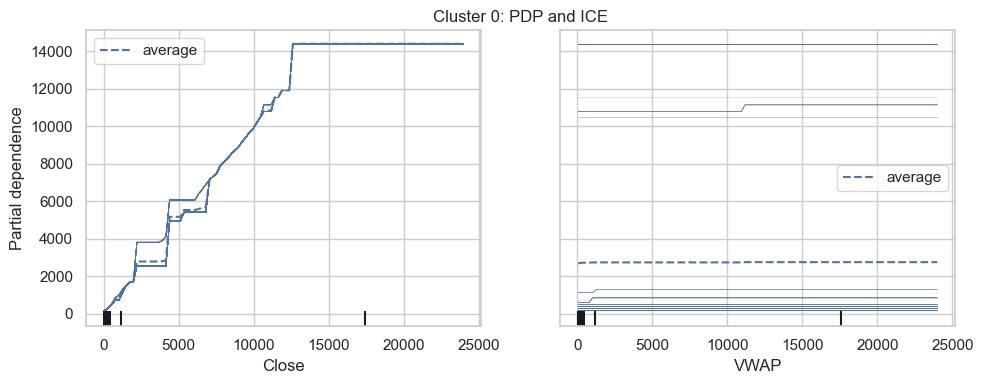

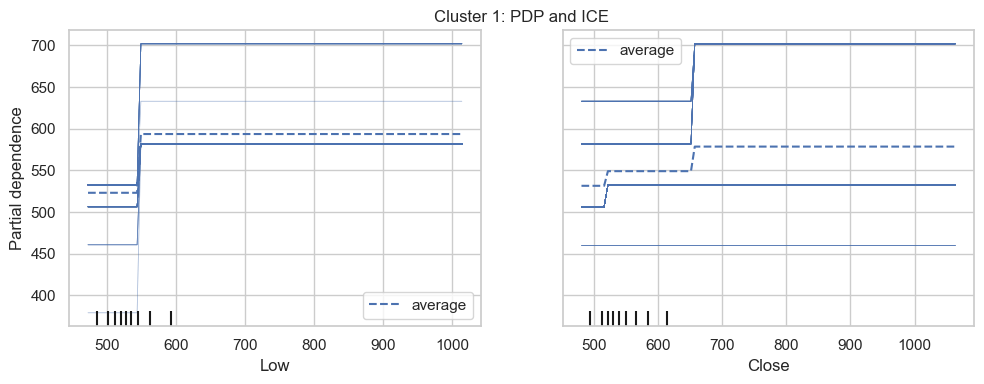

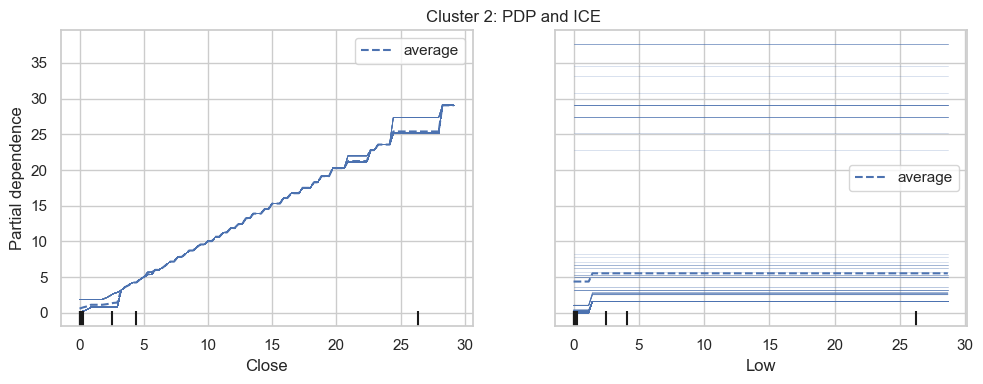

In [17]:
for cluster_id, tree in cluster_tree_models.items():
    cluster_validation = validation_df[validation_df["asset_cluster"] == cluster_id]
    if len(cluster_validation) == 0:
        continue

    features_to_plot = cluster_selected_features[cluster_id][:2]
    X_plot = cluster_validation.sample(min(200, len(cluster_validation)), random_state=SEED)[
        candidate_features
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    PartialDependenceDisplay.from_estimator(
        tree,
        X_plot,
        features=features_to_plot,
        kind="both",
        ax=ax,
    )
    ax.set_title(f"Cluster {cluster_id}: PDP and ICE")
    plt.tight_layout()
    plt.show()


SHAP summary for cluster: 0


/var/folders/m_/c2844y4966x7ns3bps1qcy800000gn/T/ipykernel_8824/3196383210.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


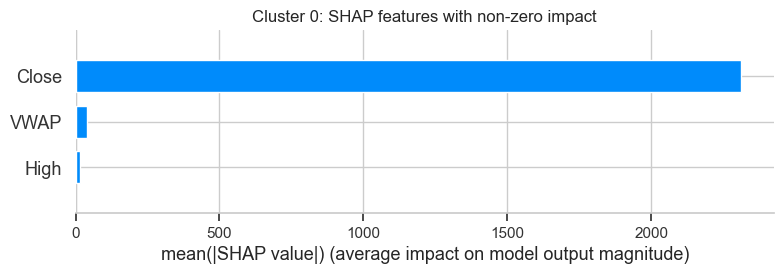

In [18]:
if shap_available and len(shap_values_by_cluster) > 0:
    example_cluster = sorted(shap_values_by_cluster.keys())[0]
    shap_values = shap_values_by_cluster[example_cluster]
    X_shap = shap_data_by_cluster[example_cluster]

    shap_importance = pd.DataFrame(
        {
            "feature": X_shap.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }
    ).sort_values("mean_abs_shap", ascending=False)

    important_shap_features = shap_importance[
        shap_importance["mean_abs_shap"] > 0
    ].head(8)["feature"].tolist()

    if len(important_shap_features) > 0:
        feature_positions = [list(X_shap.columns).index(feature) for feature in important_shap_features]

        print("SHAP summary for cluster:", example_cluster)
        shap.summary_plot(
            shap_values[:, feature_positions],
            X_shap[important_shap_features],
            plot_type="bar",
            max_display=len(important_shap_features),
            show=False,
        )
        plt.title(f"Cluster {example_cluster}: SHAP features with non-zero impact")
        plt.show()
    else:
        print("No non-zero SHAP values to plot.")


### Final include / neglect decision for Ridge Regression

This is the final decision step before the Ridge models. For each cluster, the table below shows exactly which features go into the Ridge regression and which features are left out.

A feature is included when it is one of the strongest features after the decision-tree and SHAP analysis. PDP and ICE plots are then used as a visual check for the strongest selected features. A feature is neglected when it has low support in the analysis or when it is useful for clustering/context but not useful inside a one-asset Ridge model.


In [19]:
feature_selection_rule = pd.DataFrame(
    [
        {
            "decision": "include in Ridge",
            "rule": "eligible feature and ranked inside the top features for its cluster",
        },
        {
            "decision": "do not include in Ridge",
            "rule": "low feature importance or useful only for clustering/context",
        },
    ]
)

ridge_feature_decisions = (
    feature_decision_table[
        [
            "cluster",
            "feature",
            "decision",
            "tree_rank",
            "shap_rank",
            "combined_rank",
            "reason",
        ]
    ]
    .copy()
    .sort_values(["cluster", "decision", "combined_rank"])
)

ridge_features_by_cluster = {}
ridge_neglected_features_by_cluster = {}

for cluster_id in sorted(ridge_feature_decisions["cluster"].unique()):
    cluster_decisions = ridge_feature_decisions[
        ridge_feature_decisions["cluster"] == cluster_id
    ]
    ridge_features_by_cluster[cluster_id] = cluster_decisions[
        cluster_decisions["decision"] == "include in Ridge"
    ]["feature"].tolist()
    ridge_neglected_features_by_cluster[cluster_id] = cluster_decisions[
        cluster_decisions["decision"] == "do not include in Ridge"
    ]["feature"].tolist()

ridge_feature_summary = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "features_included_in_ridge": ridge_features_by_cluster[cluster_id],
            "features_not_included_in_ridge": ridge_neglected_features_by_cluster[cluster_id],
        }
        for cluster_id in ridge_features_by_cluster
    ]
)

display(feature_selection_rule)
display(ridge_feature_decisions)
display(ridge_feature_summary)


,decision,rule
0,include in Ridge,eligible feature and ranked inside the top fea...
1,do not include in Ridge,low feature importance or useful only for clus...


,cluster,feature,decision,tree_rank,shap_rank,combined_rank,reason
8,0,asset_cluster,do not include in Ridge,9.0,4.0,13.0,"context or cluster feature, not used in the fi..."
7,0,Weight,do not include in Ridge,8.0,9.0,17.0,"context or cluster feature, not used in the fi..."
11,0,close_vwap_gap_pct,do not include in Ridge,12.0,12.0,24.0,low importance compared with the selected feat...
12,0,count_log,do not include in Ridge,13.0,14.0,27.0,low importance compared with the selected feat...
15,0,high_low_range_pct,do not include in Ridge,16.0,11.0,27.0,low importance compared with the selected feat...
...,...,...,...,...,...,...,...
61,2,High,include in Ridge,4.0,4.0,8.0,selected from decision-tree importance and SHA...
62,2,Count,include in Ridge,5.0,6.0,11.0,selected from decision-tree importance and SHA...
63,2,Open,include in Ridge,6.0,7.0,13.0,selected from decision-tree importance and SHA...
64,2,Volume,include in Ridge,7.0,8.0,15.0,selected from decision-tree importance and SHA...


,cluster,features_included_in_ridge,features_not_included_in_ridge
0,0,"[Close, VWAP, High, Count, Low, Open, Volume, ...","[asset_cluster, Weight, close_vwap_gap_pct, co..."
1,1,"[Low, Close, VWAP, Open, Count, High, Volume, ...","[asset_cluster, Weight, close_vwap_gap_pct, co..."
2,2,"[Close, Low, VWAP, High, Count, Open, Volume, ...","[asset_cluster, Weight, close_vwap_gap_pct, co..."


## Asset-specific Ridge regressions

Finally, we train one Ridge Regression model per asset. The regression uses the 70/20/10 split explicitly: training data fits the model, validation data chooses the Ridge `alpha`, and the test data measures final performance. The features are not chosen inside the Ridge loop. They come directly from the final include/neglect table above.


In [20]:
ridge_alpha_values = [0.1, 1.0, 10.0, 100.0]

asset_models = {}
asset_model_rows = []
asset_alpha_rows = []
asset_prediction_frames = []
coefficient_rows = []

for asset_name in sorted(train_df["Asset_Name"].unique()):
    asset_train = train_df[train_df["Asset_Name"] == asset_name]
    asset_validation = validation_df[validation_df["Asset_Name"] == asset_name]
    asset_test = test_df[test_df["Asset_Name"] == asset_name]

    if len(asset_train) < 50 or len(asset_validation) == 0 or len(asset_test) == 0:
        continue

    cluster_id = asset_train["asset_cluster"].iloc[0]
    selected_features = ridge_features_by_cluster[cluster_id]
    neglected_features = ridge_neglected_features_by_cluster[cluster_id]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(asset_train[selected_features])
    X_validation_scaled = scaler.transform(asset_validation[selected_features])

    alpha_scores = []

    for alpha in ridge_alpha_values:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train_scaled, asset_train["future_price"])
        validation_pred = ridge.predict(X_validation_scaled)

        validation_mae = mean_absolute_error(asset_validation["future_price"], validation_pred)
        validation_rmse = np.sqrt(
            mean_squared_error(asset_validation["future_price"], validation_pred)
        )
        validation_r2 = r2_score(asset_validation["future_price"], validation_pred)

        alpha_scores.append(
            {
                "alpha": alpha,
                "validation_MAE": validation_mae,
                "validation_RMSE": validation_rmse,
                "validation_R2": validation_r2,
            }
        )
        asset_alpha_rows.append(
            {
                "Asset_Name": asset_name,
                "cluster": cluster_id,
                "alpha": alpha,
                "validation_MAE": validation_mae,
                "validation_RMSE": validation_rmse,
                "validation_R2": validation_r2,
            }
        )

    best_alpha_row = pd.DataFrame(alpha_scores).sort_values("validation_MAE").iloc[0]
    best_alpha = best_alpha_row["alpha"]

    asset_train_validation = pd.concat([asset_train, asset_validation], axis=0)

    scaler = StandardScaler()
    X_train_validation_scaled = scaler.fit_transform(
        asset_train_validation[selected_features]
    )
    X_test_scaled = scaler.transform(asset_test[selected_features])

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(
        X_train_validation_scaled,
        asset_train_validation["future_price"],
    )

    test_pred = ridge.predict(X_test_scaled)

    raw_coefficients = ridge.coef_ / scaler.scale_
    raw_intercept = ridge.intercept_ - np.sum(ridge.coef_ * scaler.mean_ / scaler.scale_)
    raw_coefficient_dict = dict(zip(selected_features, raw_coefficients))

    asset_models[asset_name] = {
        "model": ridge,
        "scaler": scaler,
        "features": selected_features,
        "neglected_features": neglected_features,
        "cluster": cluster_id,
        "best_alpha": best_alpha,
        "raw_intercept": raw_intercept,
        "raw_coefficients": raw_coefficient_dict,
    }

    coefficient_rows.append(
        {
            "Asset_Name": asset_name,
            "cluster": cluster_id,
            "term": "intercept",
            "coefficient_for_raw_feature": raw_intercept,
            "scaled_model_coefficient": np.nan,
            "feature_mean_used_for_scaling": np.nan,
            "feature_scale_used_for_scaling": np.nan,
            "formula": "start prediction with this intercept",
        }
    )

    for feature, scaled_coef, raw_coef, feature_mean, feature_scale in zip(
        selected_features,
        ridge.coef_,
        raw_coefficients,
        scaler.mean_,
        scaler.scale_,
    ):
        coefficient_rows.append(
            {
                "Asset_Name": asset_name,
                "cluster": cluster_id,
                "term": feature,
                "coefficient_for_raw_feature": raw_coef,
                "scaled_model_coefficient": scaled_coef,
                "feature_mean_used_for_scaling": feature_mean,
                "feature_scale_used_for_scaling": feature_scale,
                "formula": f"add coefficient * {feature}",
            }
        )

    asset_model_rows.append(
        {
            "Asset_Name": asset_name,
            "cluster": cluster_id,
            "selected_features": selected_features,
            "neglected_features": neglected_features,
            "best_alpha": best_alpha,
            "validation_MAE": best_alpha_row["validation_MAE"],
            "validation_RMSE": best_alpha_row["validation_RMSE"],
            "validation_R2": best_alpha_row["validation_R2"],
            "test_MAE": mean_absolute_error(asset_test["future_price"], test_pred),
            "test_RMSE": np.sqrt(mean_squared_error(asset_test["future_price"], test_pred)),
            "test_MAPE_percent": np.mean(
                np.abs((asset_test["future_price"] - test_pred) / asset_test["future_price"])
            )
            * 100,
            "test_R2": r2_score(asset_test["future_price"], test_pred),
            "train_rows": len(asset_train),
            "validation_rows": len(asset_validation),
            "test_rows": len(asset_test),
        }
    )

    asset_predictions = asset_test[["timestamp", "Asset_Name", "Close", "future_price"]].copy()
    asset_predictions["predicted_future_price"] = test_pred
    asset_predictions["error"] = (
        asset_predictions["future_price"] - asset_predictions["predicted_future_price"]
    )
    asset_predictions["abs_error"] = asset_predictions["error"].abs()
    asset_prediction_frames.append(asset_predictions)

asset_alpha_results = pd.DataFrame(asset_alpha_rows)
asset_model_results = pd.DataFrame(asset_model_rows).sort_values("test_MAE")
ridge_coefficients = pd.DataFrame(coefficient_rows)
asset_predictions = pd.concat(asset_prediction_frames, ignore_index=True)

print("Asset Ridge models trained:", len(asset_model_results))
display(
    asset_model_results[
        ["Asset_Name", "cluster", "best_alpha", "test_MAE", "test_MAPE_percent", "test_R2"]
    ].round(4)
)


Asset Ridge models trained: 14


,Asset_Name,cluster,best_alpha,test_MAE,test_MAPE_percent,test_R2
13,TRON,2,1.0,0.0017,2.0364,0.9925
4,Dogecoin,2,10.0,0.0061,2.7950,0.9923
12,Stellar,2,0.1,0.0088,2.1666,0.9859
3,Cardano,2,0.1,0.0294,2.0951,0.9944
8,IOTA,2,0.1,0.0317,2.5656,0.9910
5,EOS.IO,2,0.1,0.1224,2.2188,0.9832
7,Ethereum Classic,2,0.1,1.0873,2.3595,0.9933
9,Litecoin,0,0.1,3.8628,1.9693,0.9882
11,Monero,0,0.1,5.1080,1.9377,0.9881
0,Binance Coin,2,0.1,6.7493,2.0556,0.9950


## Final performance measures, coefficients, and graphs

This is the final regression output. The performance measures are calculated on the 20% test set. The coefficient table contains the actual raw-feature coefficients that can be used in Excel or Python:

`predicted_future_price = intercept + sum(coefficient * feature_value)`


,requested_share,actual_rows,actual_share,start,end,model_use
train,0.7,72958,0.700038,2018-01-02 00:00:00,2020-09-13 12:00:00,fit Ridge models
test,0.2,20832,0.199885,2021-01-15 20:00:00,2021-09-20 16:00:00,final performance measurement
validation,0.1,10430,0.100077,2020-09-13 16:00:00,2021-01-15 16:00:00,choose Ridge alpha


,test_rows,overall_test_MAE,overall_test_RMSE,overall_test_MAPE_percent,overall_test_R2
0,20832,52.2754,228.0794,2.1181,0.9996


,Asset_Name,cluster,best_alpha,validation_MAE,test_MAE,test_RMSE,test_MAPE_percent,test_R2,train_rows,validation_rows,test_rows,selected_features
1,Bitcoin,0,0.1,224.2006,588.5210,843.9641,1.3423,0.9916,5914,745,1488,"[Close, VWAP, High, Count, Low, Open, Volume, ..."
6,Ethereum,0,0.1,8.3600,41.0033,59.6398,1.7576,0.9932,5914,745,1488,"[Close, VWAP, High, Count, Low, Open, Volume, ..."
11,Monero,0,0.1,1.9741,5.1080,7.8410,1.9377,0.9881,5912,745,1488,"[Close, VWAP, High, Count, Low, Open, Volume, ..."
2,Bitcoin Cash,0,0.1,4.6785,13.5678,22.9022,1.9591,0.9884,5914,745,1488,"[Close, VWAP, High, Count, Low, Open, Volume, ..."
9,Litecoin,0,0.1,1.4023,3.8628,5.8880,1.9693,0.9882,5914,745,1488,"[Close, VWAP, High, Count, Low, Open, Volume, ..."
13,TRON,2,1.0,0.0004,0.0017,0.0027,2.0364,0.9925,5693,745,1488,"[Close, Low, VWAP, High, Count, Open, Volume, ..."
0,Binance Coin,2,0.1,0.3799,6.7493,10.6106,2.0556,0.9950,5900,745,1488,"[Close, Low, VWAP, High, Count, Open, Volume, ..."
3,Cardano,2,0.1,0.0027,0.0294,0.0453,2.0951,0.9944,5276,745,1488,"[Close, Low, VWAP, High, Count, Open, Volume, ..."
12,Stellar,2,0.1,0.0031,0.0088,0.0134,2.1666,0.9859,5616,745,1488,"[Close, Low, VWAP, High, Count, Open, Volume, ..."
5,EOS.IO,2,0.1,0.0353,0.1224,0.2292,2.2188,0.9832,5914,745,1488,"[Close, Low, VWAP, High, Count, Open, Volume, ..."


,Asset_Name,cluster,term,coefficient_for_raw_feature,formula
1,Binance Coin,2,Close,7.292654e-01,add coefficient * Close
5,Binance Coin,2,Count,7.346265e-07,add coefficient * Count
4,Binance Coin,2,High,4.940508e-02,add coefficient * High
2,Binance Coin,2,Low,3.854636e-02,add coefficient * Low
6,Binance Coin,2,Open,2.209480e-02,add coefficient * Open
...,...,...,...,...,...
123,TRON,2,Open,1.273114e-01,add coefficient * Open
120,TRON,2,VWAP,7.585640e-02,add coefficient * VWAP
124,TRON,2,Volume,6.848818e-14,add coefficient * Volume
125,TRON,2,candle_return,3.120730e-03,add coefficient * candle_return


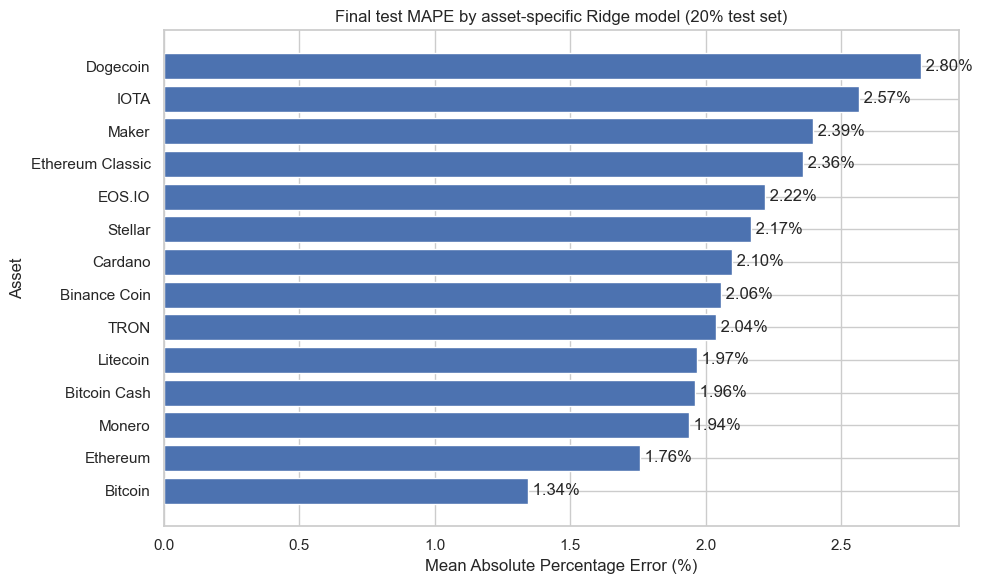

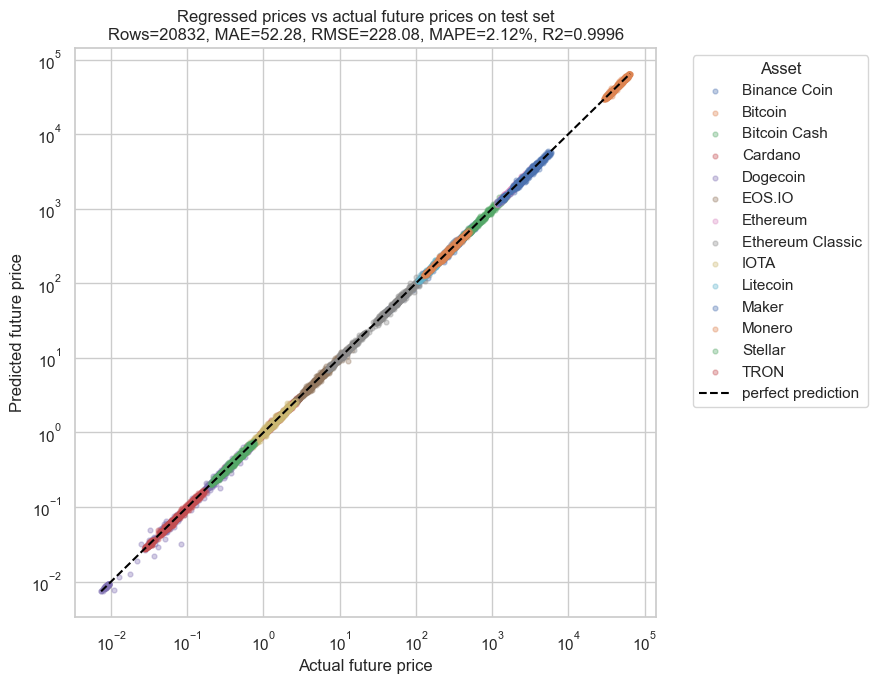

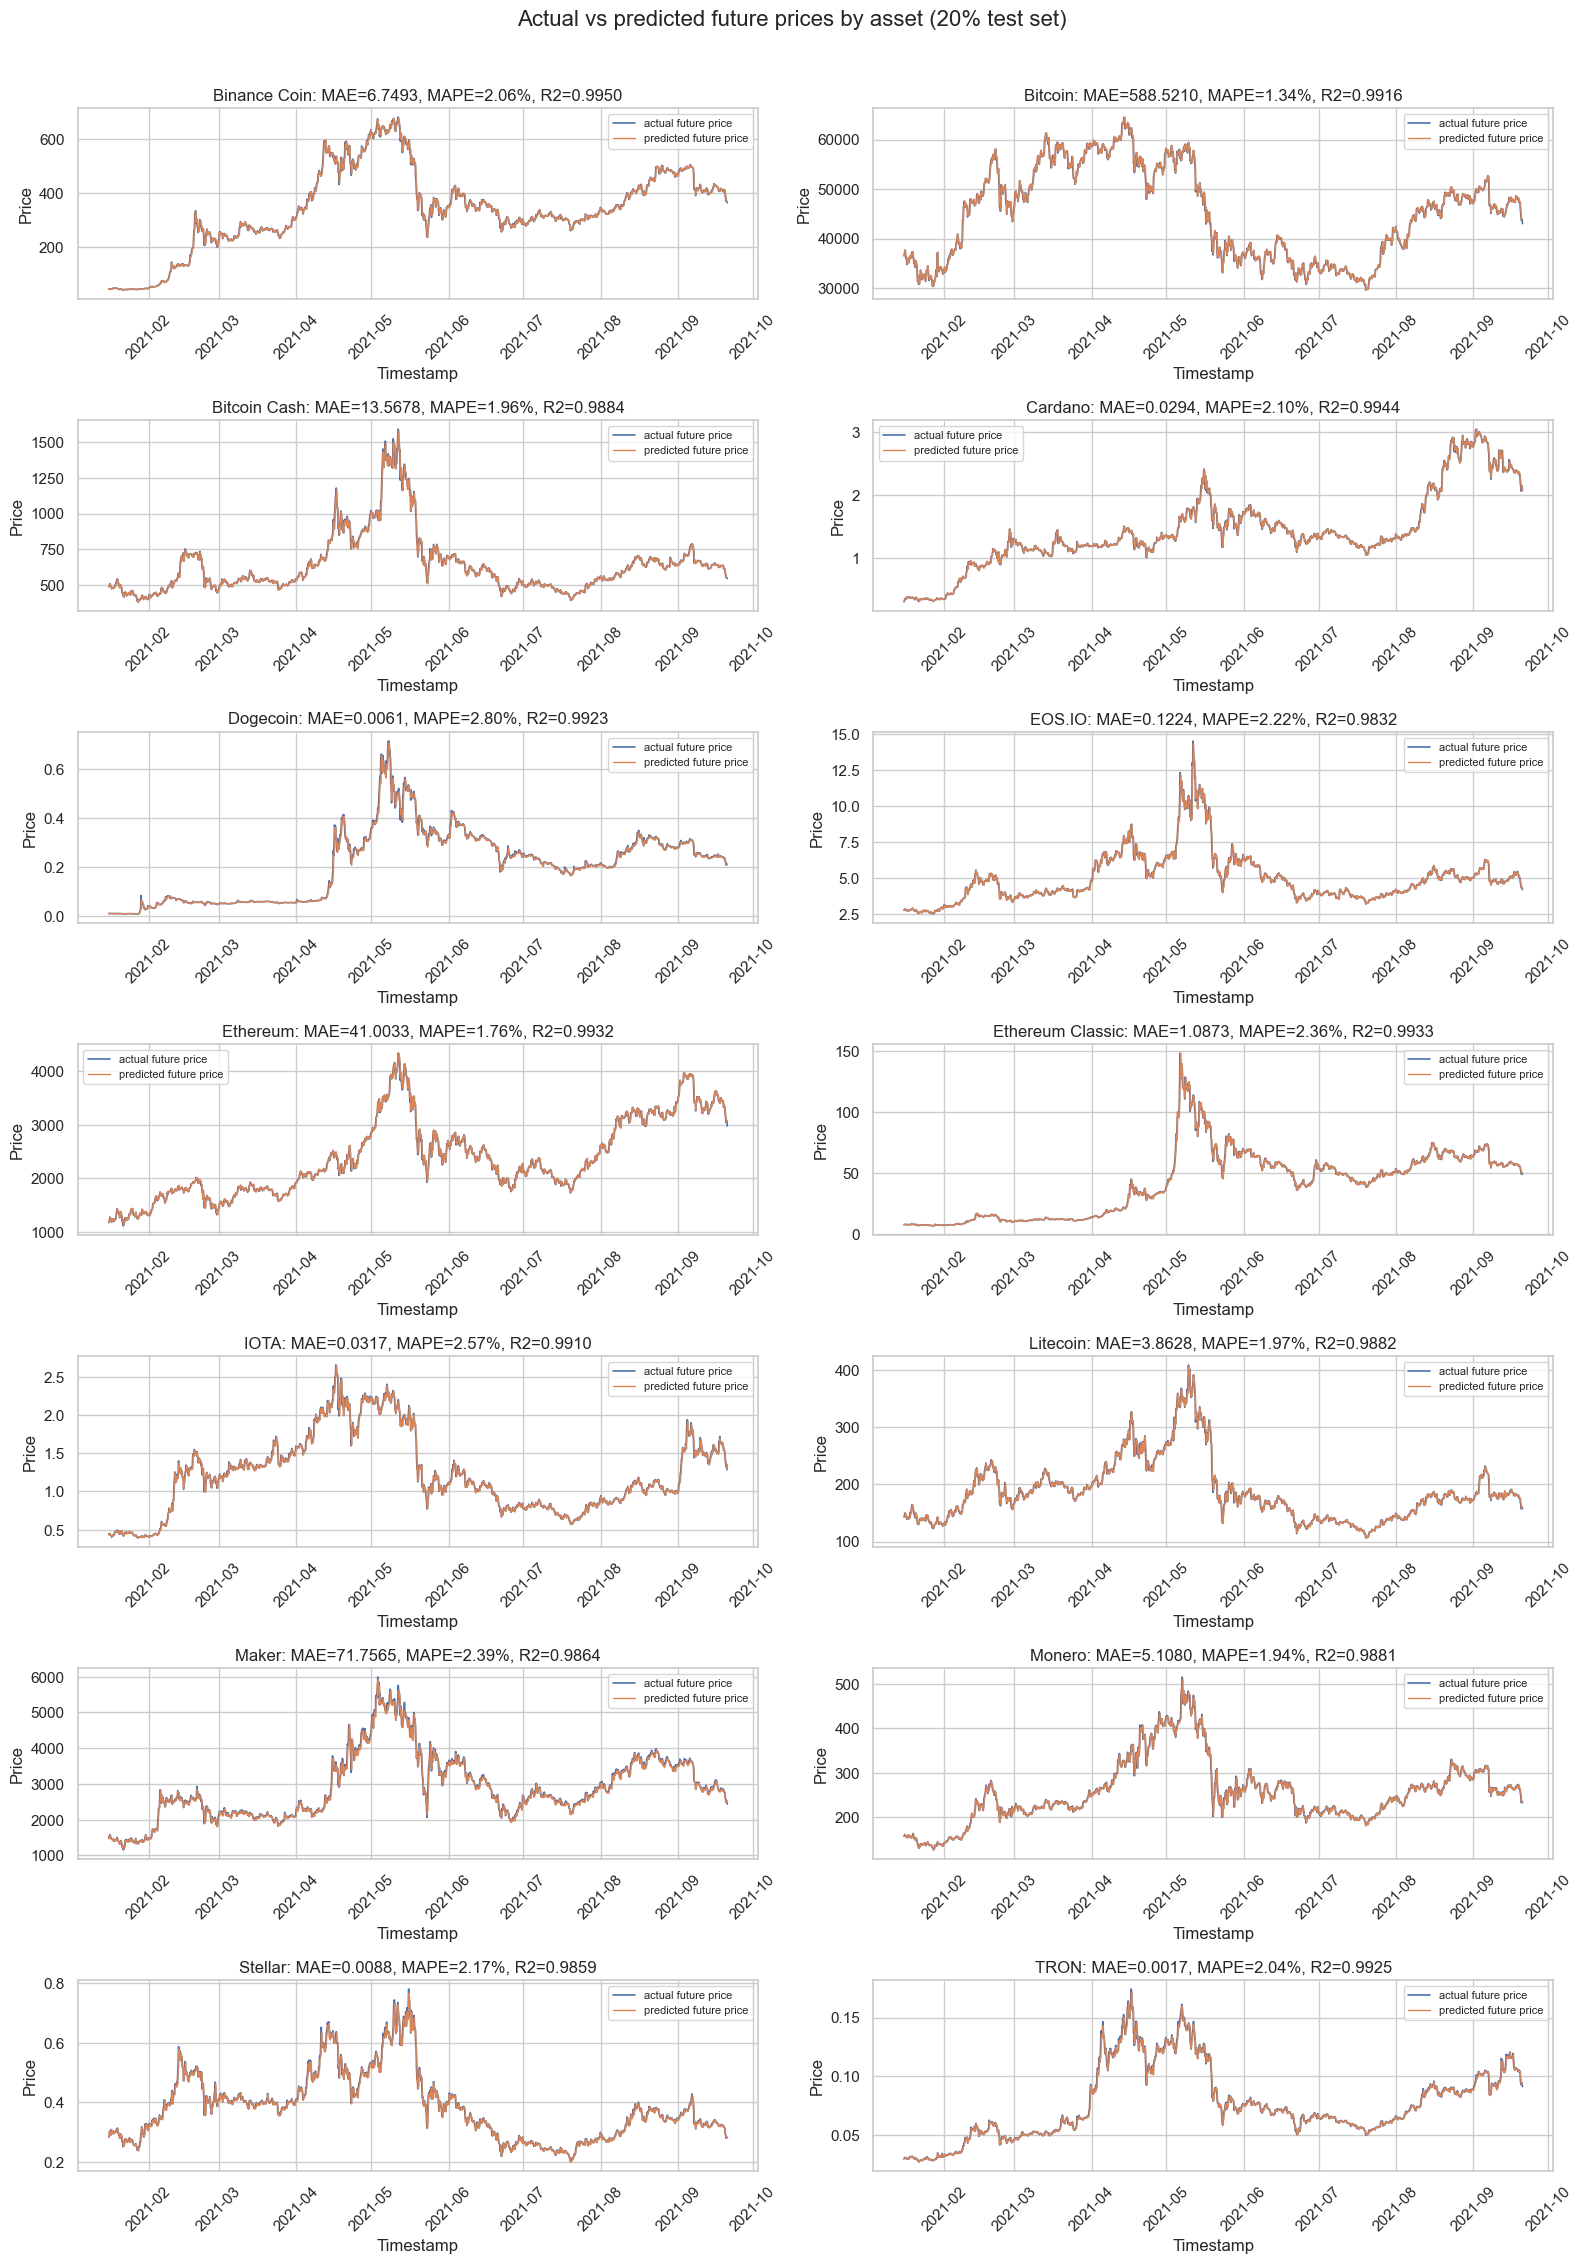

In [21]:
overall_performance = pd.DataFrame(
    [
        {
            "test_rows": len(asset_predictions),
            "overall_test_MAE": mean_absolute_error(
                asset_predictions["future_price"],
                asset_predictions["predicted_future_price"],
            ),
            "overall_test_RMSE": np.sqrt(
                mean_squared_error(
                    asset_predictions["future_price"],
                    asset_predictions["predicted_future_price"],
                )
            ),
            "overall_test_MAPE_percent": np.mean(
                np.abs(
                    (
                        asset_predictions["future_price"]
                        - asset_predictions["predicted_future_price"]
                    )
                    / asset_predictions["future_price"]
                )
            )
            * 100,
            "overall_test_R2": r2_score(
                asset_predictions["future_price"],
                asset_predictions["predicted_future_price"],
            ),
        }
    ]
)

performance_columns = [
    "Asset_Name",
    "cluster",
    "best_alpha",
    "validation_MAE",
    "test_MAE",
    "test_RMSE",
    "test_MAPE_percent",
    "test_R2",
    "train_rows",
    "validation_rows",
    "test_rows",
    "selected_features",
]

final_performance = asset_model_results[performance_columns].sort_values("test_MAPE_percent")

usable_coefficients = ridge_coefficients[
    [
        "Asset_Name",
        "cluster",
        "term",
        "coefficient_for_raw_feature",
        "formula",
    ]
].sort_values(["Asset_Name", "term"])

display(split_summary)
display(overall_performance.round(4))
display(final_performance.round(4))
display(usable_coefficients)

performance_for_plot = final_performance.sort_values("test_MAPE_percent", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(performance_for_plot["Asset_Name"], performance_for_plot["test_MAPE_percent"])
plt.gca().invert_yaxis()
plt.title("Final test MAPE by asset-specific Ridge model (20% test set)")
plt.xlabel("Mean Absolute Percentage Error (%)")
plt.ylabel("Asset")

for y_position, value in enumerate(performance_for_plot["test_MAPE_percent"]):
    plt.text(value, y_position, f" {value:.2f}%", va="center")

plt.tight_layout()
plt.show()

scatter_data = asset_predictions[
    (asset_predictions["future_price"] > 0)
    & (asset_predictions["predicted_future_price"] > 0)
].copy()

overall_mae = overall_performance.loc[0, "overall_test_MAE"]
overall_rmse = overall_performance.loc[0, "overall_test_RMSE"]
overall_mape = overall_performance.loc[0, "overall_test_MAPE_percent"]
overall_r2 = overall_performance.loc[0, "overall_test_R2"]

min_price = min(
    scatter_data["future_price"].min(),
    scatter_data["predicted_future_price"].min(),
)
max_price = max(
    scatter_data["future_price"].max(),
    scatter_data["predicted_future_price"].max(),
)

plt.figure(figsize=(9, 7))
for asset_name in sorted(scatter_data["Asset_Name"].unique()):
    asset_plot = scatter_data[scatter_data["Asset_Name"] == asset_name]
    plt.scatter(
        asset_plot["future_price"],
        asset_plot["predicted_future_price"],
        s=12,
        alpha=0.35,
        label=asset_name,
    )

plt.plot([min_price, max_price], [min_price, max_price], "--", color="black", label="perfect prediction")
plt.xscale("log")
plt.yscale("log")
plt.title(
    "Regressed prices vs actual future prices on test set\n"
    f"Rows={len(asset_predictions)}, MAE={overall_mae:.2f}, RMSE={overall_rmse:.2f}, "
    f"MAPE={overall_mape:.2f}%, R2={overall_r2:.4f}"
)
plt.xlabel("Actual future price")
plt.ylabel("Predicted future price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Asset")
plt.tight_layout()
plt.show()

asset_names = sorted(asset_predictions["Asset_Name"].unique())
n_cols = 2
n_rows = int(np.ceil(len(asset_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows), sharex=False)
axes = axes.flatten()

for ax, asset_name in zip(axes, asset_names):
    plot_data = asset_predictions[
        asset_predictions["Asset_Name"] == asset_name
    ].sort_values("timestamp")
    asset_row = final_performance[final_performance["Asset_Name"] == asset_name].iloc[0]

    ax.plot(
        plot_data["timestamp"],
        plot_data["future_price"],
        label="actual future price",
        linewidth=1.2,
    )
    ax.plot(
        plot_data["timestamp"],
        plot_data["predicted_future_price"],
        label="predicted future price",
        linewidth=1.0,
    )
    ax.set_title(
        f"{asset_name}: MAE={asset_row['test_MAE']:.4f}, "
        f"MAPE={asset_row['test_MAPE_percent']:.2f}%, R2={asset_row['test_R2']:.4f}"
    )
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

for ax in axes[len(asset_names):]:
    ax.remove()

fig.suptitle("Actual vs predicted future prices by asset (20% test set)", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


### Example prediction using the saved Ridge coefficients


In [22]:
def predict_future_price_for_asset(asset_name, parameters):
    model_info = asset_models[asset_name]
    selected_features = model_info["features"]

    prediction = model_info["raw_intercept"]
    for feature in selected_features:
        prediction = prediction + model_info["raw_coefficients"][feature] * parameters[feature]
    return prediction


example_asset = asset_model_results.iloc[0]["Asset_Name"]
example_features = asset_models[example_asset]["features"]
example_parameters = (
    test_df[test_df["Asset_Name"] == example_asset]
    .iloc[-1][example_features]
    .to_dict()
)

example_prediction = predict_future_price_for_asset(example_asset, example_parameters)
example_coefficients = usable_coefficients[
    usable_coefficients["Asset_Name"] == example_asset
]

print("Example asset:", example_asset)
print("Selected features:", example_features)
print("Predicted future price:", example_prediction)
display(pd.DataFrame([example_parameters]))
display(example_coefficients)


Example asset: TRON
Selected features: ['Close', 'Low', 'VWAP', 'High', 'Count', 'Open', 'Volume', 'candle_return']
Predicted future price: 0.09334355634735267


,Close,Low,VWAP,High,Count,Open,Volume,candle_return
0,0.093552,0.091775,0.093809,0.0958,133176.0,0.094714,6.107468e+08,-0.012274


,Asset_Name,cluster,term,coefficient_for_raw_feature,formula
118,TRON,2,Close,7.055218e-01,add coefficient * Close
122,TRON,2,Count,-2.165842e-09,add coefficient * Count
121,TRON,2,High,4.716600e-02,add coefficient * High
119,TRON,2,Low,4.213481e-02,add coefficient * Low
123,TRON,2,Open,1.273114e-01,add coefficient * Open
120,TRON,2,VWAP,7.585640e-02,add coefficient * VWAP
124,TRON,2,Volume,6.848818e-14,add coefficient * Volume
125,TRON,2,candle_return,3.120730e-03,add coefficient * candle_return
117,TRON,2,intercept,6.606194e-05,start prediction with this intercept


## Conclusion

The workflow is:

1. Cluster the assets based on historical behavior.
2. Analyze feature importance inside each cluster using decision trees with different depths.
3. Use SHAP, PDP, and ICE plots to support the feature decisions.
4. Explicitly mark features as `include in Ridge` or `do not include in Ridge` for each cluster.
5. Train one Ridge Regression model per asset using the 70/20/10 split.
6. Report validation and test performance, usable Ridge coefficients, and actual vs predicted price graphs.

This keeps the final model simple while still using clustering and feature analysis to decide which inputs should go into each asset's regression model.
